<a href="https://colab.research.google.com/github/kayagwen/kayahigginbotham_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [30]:
X = data[['Age', 'Salary']]
Y = data['Purchased']

print('X shape:', X.shape)
print('Y distribution:\n', Y.value_counts())

X shape: (400, 2)
Y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0, stratify=Y
)
print('Train size:', X_train.shape[0], 'Test size:', X_test.shape[0])

Train size: 300 Test size: 100


### Step 4: Feature Scaling

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('Scaling complete.')


Scaling complete.


### Step 5: Train Logistic Regression Model

In [33]:
model  = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
print('Model trained.')

Model trained.


### Step 6: Predict and Evaluate

In [34]:
Y_pred = model.predict(X_test)
acc = accuracy_score(Y_test, Y_test)
cm = confusion_matrix(Y_test, Y_test)
print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(Y_test, Y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[64  0]
 [ 0 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86        64
           1       0.79      0.64      0.71        36

    accuracy                           0.81       100
   macro avg       0.81      0.77      0.78       100
weighted avg       0.81      0.81      0.80       100



### Step 7: Visualization of Decision Regions

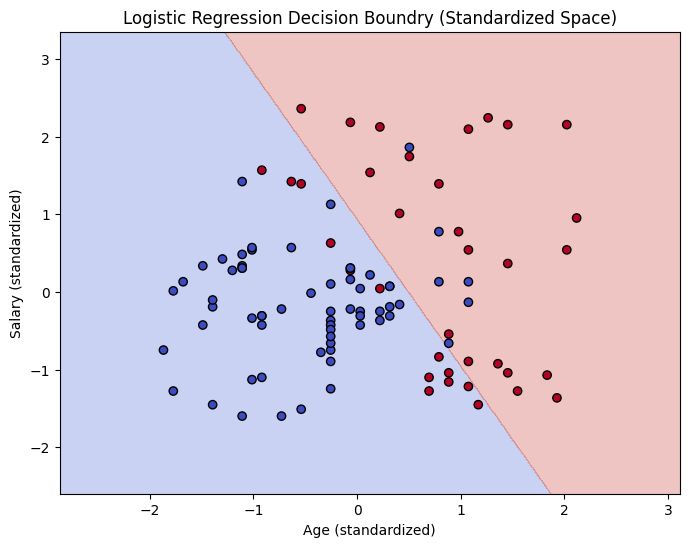

In [35]:
import numpy as np
import matplotlib.pyplot as plt

X_set, Y_set = X_test[:, :2], Y_test.values
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train[:, :2], Y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)

Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:,0], X_set[:, 1], c=Y_set, edgecolor= 'k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundry (Standardized Space)')
plt.xlabel('Age (standardized)')
plt.ylabel('Salary (standardized)')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

# 1. Because depending on the data it's able to determin the probability of something and assigns it either a 0 or a 1 based on it's uniformity to other data.

# 2. Older people with higher salaries are more likely to purchase a car. Not super suprising haha!

# 3. Low accuracy can be cause by things like irrelevent data like extenuating circumstances or just outliers within the data.

# 4. I'm pretty new to python so I don't really have any suggestions I think would add to the improvement of accuracy for this code.